## Intro — Araucanía Case Study

This notebook downloads wind and solar resource data from ERA5 using Atlite for La Araucanía region of Chile, outputting `{identifier}_solar_power_profile.csv` and `{identifier}_wind_power_profile.csv` as hourly capacity factor time-series at 0.25° resolution. Land availability is computed using MODIS, WDPA protected areas and SRTM slope data. All outputs are written to `./data_Araucania/`.

Adapted from the Ukraine pipeline. Identifier: `CHI_ARN`. Offshore: disabled (land-only region).

## Environment Requirement

This notebook requires the `plot-env` environment to run. Please ensure you have the environment set up with the necessary dependencies before running the cells in this notebook.

In [1]:
import atlite
import geopandas as gpd
import plotly.graph_objects as go
from shapely.geometry import Point
import os
import numpy as np
import cartopy.io.shapereader as shpreader

# Function to get the bounding box of a country using the correct shapefile
def get_country_bbox(country, land_shapefile_path, eez_shapefile_path, include_offshore):
    if include_offshore:
        gdf = gpd.read_file(eez_shapefile_path)
        country_gdf = gdf[(gdf['TERRITORY1'] == country) | (gdf['TERRITORY2'] == country)]
    else:
        gdf = gpd.read_file(land_shapefile_path)
        country_gdf = gdf[gdf['NAME'] == country]

    if not country_gdf.empty:
        bounds = country_gdf.total_bounds  # [minx, miny, maxx, maxy]
        return bounds[1], bounds[3], bounds[0], bounds[2]  # [lat_min, lat_max, lon_min, lon_max]
    else:
        raise ValueError(f"Could not find bounding box for country: {country}")

# Function to plot the bounding box against country borders
def plot_cutout_area(bbox, country, land_shapefile_path, eez_shapefile_path, include_offshore):
    lat_min, lat_max, lon_min, lon_max = bbox
    center_lat = (lat_min + lat_max) / 2
    center_lon = (lon_min + lon_max) / 2

    boundary_traces = []

    if isinstance(country, str):
        if include_offshore:
            gdf = gpd.read_file(eez_shapefile_path)
            country_gdf = gdf[(gdf['TERRITORY1'] == country) | (gdf['TERRITORY2'] == country)]
        else:
            gdf = gpd.read_file(land_shapefile_path)
            country_gdf = gdf[gdf['NAME'] == country]

        country_gdf = country_gdf.to_crs(epsg=4326)

        for _, row in country_gdf.iterrows():
            if isinstance(row.geometry, Point):
                continue
            if row.geometry.geom_type == 'Polygon':
                lon, lat = row.geometry.exterior.coords.xy
                boundary_traces.append(go.Scattermapbox(
                    lon=list(lon), lat=list(lat), mode='lines',
                    line=dict(width=1, color='blue'), showlegend=False,
                    name='Boundary' if not include_offshore else 'EEZ'
                ))
            elif row.geometry.geom_type == 'MultiPolygon':
                for polygon in row.geometry.geoms:
                    lon, lat = polygon.exterior.coords.xy
                    boundary_traces.append(go.Scattermapbox(
                        lon=list(lon), lat=list(lat), mode='lines',
                        line=dict(width=1, color='blue'), showlegend=False,
                        name='Boundary' if not include_offshore else 'EEZ'
                    ))

    fig = go.Figure(boundary_traces)
    cutout_trace = go.Scattermapbox(
        lon=[lon_min, lon_max, lon_max, lon_min, lon_min],
        lat=[lat_min, lat_min, lat_max, lat_max, lat_min],
        mode='lines', line=dict(width=2, color='red'), name='Cutout Area'
    )
    fig.add_trace(cutout_trace)
    fig.update_layout(
        title=f'Cutout Area vs. {"EEZ" if include_offshore else "Country Borders"} in {country}',
        mapbox=dict(style='carto-positron', center=dict(lat=center_lat, lon=center_lon), zoom=5),
        width=1000, height=800, margin=dict(l=10, r=10, t=40, b=10)
    )
    fig.show()

# Function to create and prepare the cutout for a specified time range
def create_cutout(bbox, identifier, start_date, end_date, save_path):
    cutout = atlite.Cutout(
        path=os.path.join(save_path, f"{identifier}_{start_date}_to_{end_date}.nc"),
        module="era5",
        x=slice(bbox[2], bbox[3]),  # lon_min, lon_max
        y=slice(bbox[0], bbox[1]),  # lat_min, lat_max
        time=slice(start_date, end_date)
    )
    print(cutout)
    cutout.prepare()
    return cutout

Boundary file found — loading from ./data_Araucania/CHI_ARN_boundary.geojson
Region:       RegiÃ³n de La AraucanÃ­a
Geometry:     Polygon
Bounding box: lat -39.6371 → -37.5817,  lon -73.5190 → -70.8274


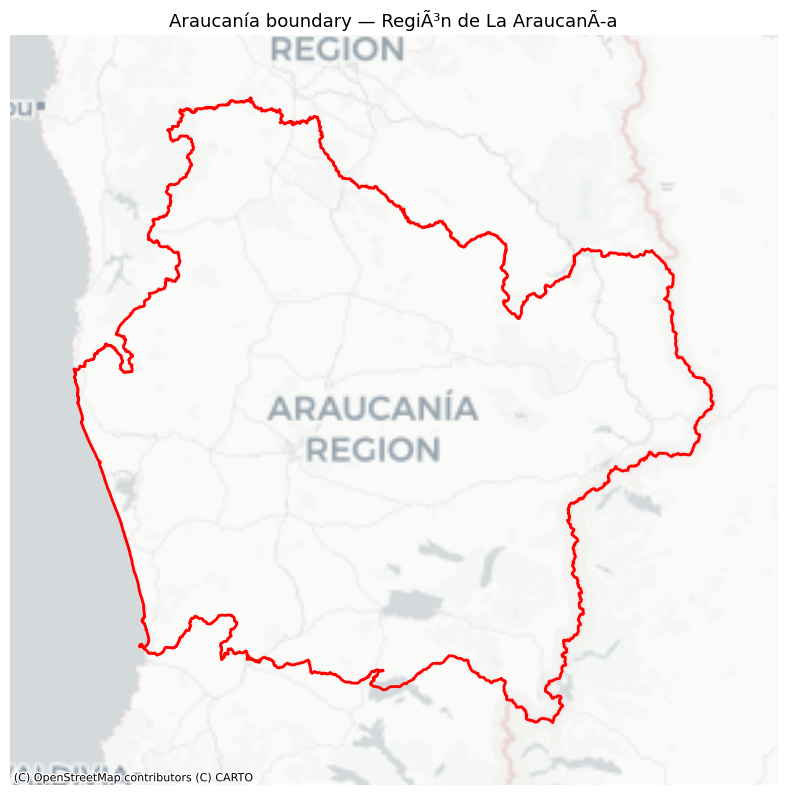

In [ ]:
import geopandas as gpd
import requests
import cartopy.io.shapereader as shpreader
import os

# Path constructed inline — matches Config cell values
_boundary_path = "../data_Araucania/CHI_ARN_boundary.geojson"
os.makedirs("../data_Araucania", exist_ok=True)

if os.path.exists(_boundary_path):
    # ── Already on disk: load and skip all downloads ──────────────────────
    print(f"Boundary file found — loading from {_boundary_path}")
    region_boundary = gpd.read_file(_boundary_path).to_crs("EPSG:4326")
    if 'NAME_1' not in region_boundary.columns and 'name' in region_boundary.columns:
        region_boundary = region_boundary.rename(columns={'name': 'NAME_1'})

else:
    # ── Source 1: geoBoundaries API ───────────────────────────────────────
    chile_admin1 = None
    try:
        print("Trying geoBoundaries API...")
        resp = requests.get(
            "https://www.geoboundaries.org/api/current/gbOpen/CHL/ADM1/",
            timeout=15
        )
        resp.raise_for_status()
        chile_admin1 = gpd.read_file(resp.json()["gjDownloadURL"])
        chile_admin1 = chile_admin1.rename(columns={"shapeName": "NAME_1"})
        print("  geoBoundaries: OK")
    except Exception as e:
        print(f"  geoBoundaries failed: {e}")

    # ── Source 2: GADM GeoPackage ─────────────────────────────────────────
    if chile_admin1 is None:
        try:
            print("Trying GADM GeoPackage...")
            local_gpkg = "../data_Araucania/gadm41_CHL.gpkg"
            r = requests.get(
                "https://geodata.ucdavis.edu/gadm/gadm4.1/gpkg/gadm41_CHL.gpkg",
                stream=True, timeout=60
            )
            r.raise_for_status()
            with open(local_gpkg, "wb") as f:
                for chunk in r.iter_content(chunk_size=8192):
                    f.write(chunk)
            chile_admin1 = gpd.read_file(local_gpkg, layer="ADM_ADM_1")
            print("  GADM GeoPackage: OK")
        except Exception as e:
            print(f"  GADM failed: {e}")

    # ── Source 3: Natural Earth fallback (coarse, already cached) ─────────
    if chile_admin1 is None:
        print("Falling back to Natural Earth (lower precision)...")
        shpfilename = shpreader.natural_earth(resolution='10m', category='cultural',
                                              name='admin_1_states_provinces')
        all_admin1 = gpd.read_file(shpfilename)
        chile_admin1 = all_admin1[all_admin1['admin'] == 'Chile'].rename(columns={'name': 'NAME_1'})

    region_boundary = chile_admin1[
        chile_admin1['NAME_1'].str.contains('raucan', case=False, na=False)
    ].to_crs('EPSG:4326').copy()

    if region_boundary.empty:
        print("Available regions:", chile_admin1['NAME_1'].sort_values().tolist())
        raise ValueError("Could not find Araucanía. Check region names above.")

    region_boundary = region_boundary.dissolve()
    region_boundary.to_file(_boundary_path, driver="GeoJSON")
    print(f"Boundary saved: {_boundary_path}")

# ── Shared outcome ────────────────────────────────────────────────────────────
bounds = region_boundary.total_bounds
bbox = (bounds[1], bounds[3], bounds[0], bounds[2])
print(f"Region:       {region_boundary['NAME_1'].iloc[0]}")
print(f"Geometry:     {region_boundary.geometry.geom_type.iloc[0]}")
print(f"Bounding box: lat {bbox[0]:.4f} → {bbox[1]:.4f},  lon {bbox[2]:.4f} → {bbox[3]:.4f}")

# Plot
import matplotlib.pyplot as plt
import contextily as ctx

region_webmerc = region_boundary.to_crs(epsg=3857)
fig, ax = plt.subplots(figsize=(8, 8))
region_webmerc.plot(ax=ax, facecolor='none', edgecolor='red', linewidth=2, zorder=2)
xmin, ymin, xmax, ymax = region_webmerc.total_bounds
xpad, ypad = (xmax - xmin) * 0.1, (ymax - ymin) * 0.1
ax.set_xlim(xmin - xpad, xmax + xpad)
ax.set_ylim(ymin - ypad, ymax + ypad)
ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron, zoom=7)
ax.set_title(f"Araucanía boundary — {region_boundary['NAME_1'].iloc[0]}", fontsize=13)
ax.set_axis_off()
plt.tight_layout()
plt.show()

In [ ]:
import calendar

# ── Case Study Configuration ──────────────────────────────────────────────────
IDENTIFIER       = "CHI_ARN"
INCLUDE_OFFSHORE = False
YEAR             = 2023
DATA_OUT         = "../data_Araucania"
# ─────────────────────────────────────────────────────────────────────────────

os.makedirs(DATA_OUT, exist_ok=True)

land_shapefile_path = "../data/ne_10m_admin_0_map_units/ne_10m_admin_0_map_units.shp"
eez_shapefile_path  = "../data/EEZ_land_union_v3_202003/EEZ_Land_v3_202030.shp"

# Convenience aliases used throughout notebook
identifier       = IDENTIFIER
include_offshore = INCLUDE_OFFSHORE
save_path        = DATA_OUT

# Full-year monthly date ranges
start_date = [f"{YEAR}-{m:02d}-01" for m in range(1, 13)]
end_date   = [f"{YEAR}-{m:02d}-{calendar.monthrange(YEAR, m)[1]:02d}" for m in range(1, 13)]

# Save boundary GeoJSON (used by trimming cells later)
boundary_geojson_path = os.path.join(DATA_OUT, f"{identifier}_boundary.geojson")

print(f"Identifier:       {identifier}")
print(f"Include offshore: {include_offshore}")
print(f"Output folder:    {DATA_OUT}")
print(f"Date range:       {start_date[0]} → {end_date[-1]}")
print(f"Bounding box:     {tuple(round(v, 4) for v in bbox)}")
print(f"Boundary saved:   {boundary_geojson_path}")

# Plot cutout extent against Chile land boundary
plot_cutout_area(bbox, "Chile", land_shapefile_path, eez_shapefile_path, include_offshore=False)

Identifier:       CHI_ARN
Include offshore: False
Output folder:    ./data_Araucania
Date range:       2023-01-01 → 2023-12-31
Bounding box:     (-39.6371, -37.5817, -73.519, -70.8274)
Boundary saved:   ./data_Araucania\CHI_ARN_boundary.geojson


C:\Users\Benhd\AppData\Local\Temp\ipykernel_19644\2046021776.py:55: DeprecationWarning: *scattermapbox* is deprecated! Use *scattermap* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/
  boundary_traces.append(go.Scattermapbox(
C:\Users\Benhd\AppData\Local\Temp\ipykernel_19644\2046021776.py:62: DeprecationWarning:

*scattermapbox* is deprecated! Use *scattermap* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/



In [4]:
# Create and prepare the cutout for the specified time range
# Check your CDS request status at https://cds.climate.copernicus.eu/requests?tab=all
cutouts = []
i = 1
for start, end in zip(start_date, end_date):
    if i == 1:
        cutout = create_cutout(bbox, identifier, start, end, save_path)
        i += 1
    else:
        cutout_aux = create_cutout(bbox, identifier, start, end, save_path)
        cutout = cutout.merge(cutout_aux)
        i += 1

c:\Users\Benhd\Code\envs\plot-env\Lib\site-packages\atlite\cutout.py:156: UserWarning:

Arguments module, x, y, time are ignored, since cutout is already built.



<Cutout "CHI_ARN_2023-01-01_to_2023-01-31">
 x = -73.50 ⟷ -71.00, dx = 0.25
 y = -39.50 ⟷ -37.75, dy = 0.25
 time = 2023-01-01 ⟷ 2023-01-31, dt = h
 module = era5
 prepared_features = ['height', 'wind', 'influx', 'temperature', 'runoff']
<Cutout "CHI_ARN_2023-02-01_to_2023-02-28">
 x = -73.50 ⟷ -71.00, dx = 0.25
 y = -39.50 ⟷ -37.75, dy = 0.25
 time = 2023-02-01 ⟷ 2023-02-28, dt = h
 module = era5
 prepared_features = ['height', 'wind', 'influx', 'temperature', 'runoff']


c:\Users\Benhd\Code\envs\plot-env\Lib\site-packages\atlite\cutout.py:156: UserWarning:

Arguments module, x, y, time are ignored, since cutout is already built.

c:\Users\Benhd\Code\envs\plot-env\Lib\site-packages\atlite\cutout.py:438: FutureWarning:

In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'time' ('time',) The recommendation is to set join explicitly for this case.

c:\Users\Benhd\Code\envs\plot-env\Lib\site-packages\atlite\cutout.py:438: FutureWarning:

In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_co

<Cutout "CHI_ARN_2023-03-01_to_2023-03-31">
 x = -73.50 ⟷ -71.00, dx = 0.25
 y = -39.50 ⟷ -37.75, dy = 0.25
 time = 2023-03-01 ⟷ 2023-03-31, dt = h
 module = era5
 prepared_features = ['height', 'wind', 'influx', 'temperature', 'runoff']


c:\Users\Benhd\Code\envs\plot-env\Lib\site-packages\atlite\cutout.py:438: FutureWarning:

In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.

c:\Users\Benhd\Code\envs\plot-env\Lib\site-packages\atlite\cutout.py:438: FutureWarning:

In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.

c:\Users\Benhd\Code\envs\plot-env\Lib\site-packages\atlite\cutout.py:438: FutureWarning:

In a f

...

c:\Users\Benhd\Code\envs\plot-env\Lib\site-packages\atlite\cutout.py:438: FutureWarning:

In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.

c:\Users\Benhd\Code\envs\plot-env\Lib\site-packages\atlite\cutout.py:438: FutureWarning:

In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.

c:\Users\Benhd\Code\envs\plot-env\Lib\site-packages\atlite\cutout.py:438: FutureWarning:

In a f

<Cutout "CHI_ARN_2023-11-01_to_2023-11-30">
 x = -73.50 ⟷ -71.00, dx = 0.25
 y = -39.50 ⟷ -37.75, dy = 0.25
 time = 2023-11-01 ⟷ 2023-11-30, dt = h
 module = era5
 prepared_features = ['height', 'wind', 'influx', 'temperature', 'runoff']


c:\Users\Benhd\Code\envs\plot-env\Lib\site-packages\atlite\cutout.py:438: FutureWarning:

In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.

c:\Users\Benhd\Code\envs\plot-env\Lib\site-packages\atlite\cutout.py:438: FutureWarning:

In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.

c:\Users\Benhd\Code\envs\plot-env\Lib\site-packages\atlite\cutout.py:438: FutureWarning:

In a f

<Cutout "CHI_ARN_2023-12-01_to_2023-12-31">
 x = -73.50 ⟷ -71.00, dx = 0.25
 y = -39.50 ⟷ -37.75, dy = 0.25
 time = 2023-12-01 ⟷ 2023-12-31, dt = h
 module = era5
 prepared_features = ['height', 'wind', 'influx', 'temperature', 'runoff']


c:\Users\Benhd\Code\envs\plot-env\Lib\site-packages\atlite\cutout.py:438: FutureWarning:

In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'time' ('time',) The recommendation is to set join explicitly for this case.

c:\Users\Benhd\Code\envs\plot-env\Lib\site-packages\atlite\cutout.py:438: FutureWarning:

In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.

c:\Users\Benhd\Code\envs\plot-env\Lib\site-packages\atlite\cutout.py:438: FutureWarning:

In a future versio

In [5]:
import geopandas as gpd
import numpy as np
import pandas as pd
import os
from shapely.geometry import Point

# Create a uniform layout across the grid squares using default capacity
layout = cutout.uniform_layout()

grid_cells = gpd.GeoDataFrame({
    'geometry': [Point(lon, lat).buffer(0.1) for lat in cutout.coords['y'].values for lon in cutout.coords['x'].values],
    'capacity': layout.values.flatten()
})

# Solar PV profile (CSi panel, latitude-optimal tilt)
pv_profile = cutout.pv(
    panel='CSi',
    orientation='latitude_optimal',
    layout=layout,
    shapes=grid_cells.geometry,
    per_unit=True
)

# Wind power profile (Vestas V112 3 MW)
wind_profile = cutout.wind(
    turbine='Vestas_V112_3MW',
    layout=layout,
    shapes=grid_cells.geometry,
    per_unit=True
)

pv_df   = pv_profile.to_pandas()
wind_df = wind_profile.to_pandas()

# Column names: "lat_lon" format, 2 decimal places
pv_df.columns   = [f"{lat:.2f}_{lon:.2f}" for lat in cutout.coords['y'].values for lon in cutout.coords['x'].values]
wind_df.columns = pv_df.columns

# --- Filter to grid points within the Araucanía boundary ---

def generate_grid_points_within_region(region_gdf, bbox, min_coverage=0.40):
    """Return 0.25° grid points where >= min_coverage of cell area is within the region."""
    from shapely.geometry import box as shapely_box

    lat_min, lat_max, lon_min, lon_max = bbox
    lat_pts = np.arange(np.floor(lat_min), np.ceil(lat_max) + 0.25, 0.25)
    lon_pts = np.arange(np.floor(lon_min), np.ceil(lon_max) + 0.25, 0.25)

    region_union = region_gdf.unary_union

    within = []
    for la in lat_pts:
        for lo in lon_pts:
            cell = shapely_box(lo - 0.125, la - 0.125, lo + 0.125, la + 0.125)
            if region_union.intersects(cell):
                coverage = region_union.intersection(cell).area / cell.area
                if coverage >= min_coverage:
                    within.append((la, lo))

    print(f"Grid points (coverage >= {min_coverage*100:.0f}%): {len(within)}")
    return within, bbox

filtered_grid_points, bbox = generate_grid_points_within_region(
    region_boundary, bbox, min_coverage=0.2
)

filtered_lon_lat = [f"{lat:.2f}_{lon:.2f}" for lat, lon in filtered_grid_points]

pv_df_filtered   = pv_df.loc[:, pv_df.columns.intersection(filtered_lon_lat)]
wind_df_filtered = wind_df.loc[:, wind_df.columns.intersection(filtered_lon_lat)]

pv_df_filtered   = pv_df_filtered.reindex(sorted(pv_df_filtered.columns,   key=lambda x: tuple(map(float, x.split('_')))), axis=1)
wind_df_filtered = wind_df_filtered.reindex(sorted(wind_df_filtered.columns, key=lambda x: tuple(map(float, x.split('_')))), axis=1)

pv_csv_path   = os.path.join(save_path, f"{identifier}_solar_power_profile.csv")
wind_csv_path = os.path.join(save_path, f"{identifier}_wind_power_profile.csv")

pv_df_filtered.to_csv(pv_csv_path, index_label="datetime")
wind_df_filtered.to_csv(wind_csv_path, index_label="datetime")

print(f"Solar profile saved: {pv_csv_path}  shape={pv_df_filtered.shape}")
print(f"Wind profile  saved: {wind_csv_path}  shape={wind_df_filtered.shape}")

c:\Users\Benhd\Code\envs\plot-env\Lib\site-packages\atlite\resource.py:90: FutureWarning:

'add_cutout_windspeed' for wind turbine
power curves will default to True in atlite relase v0.2.15.

C:\Users\Benhd\AppData\Local\Temp\ipykernel_19644\2746399902.py:49: DeprecationWarning:

The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.



Grid points (coverage >= 20%): 63
Solar profile saved: ./data_Araucania\CHI_ARN_solar_power_profile.csv  shape=(8760, 63)
Wind profile  saved: ./data_Araucania\CHI_ARN_wind_power_profile.csv  shape=(8760, 63)


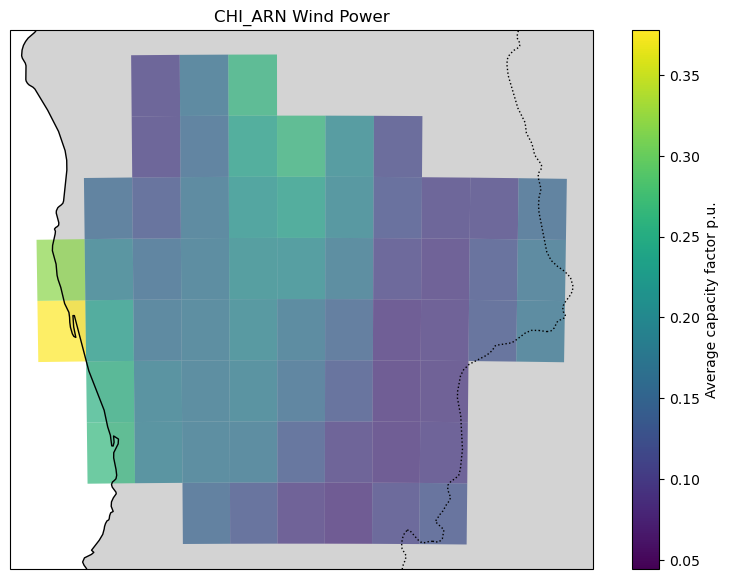

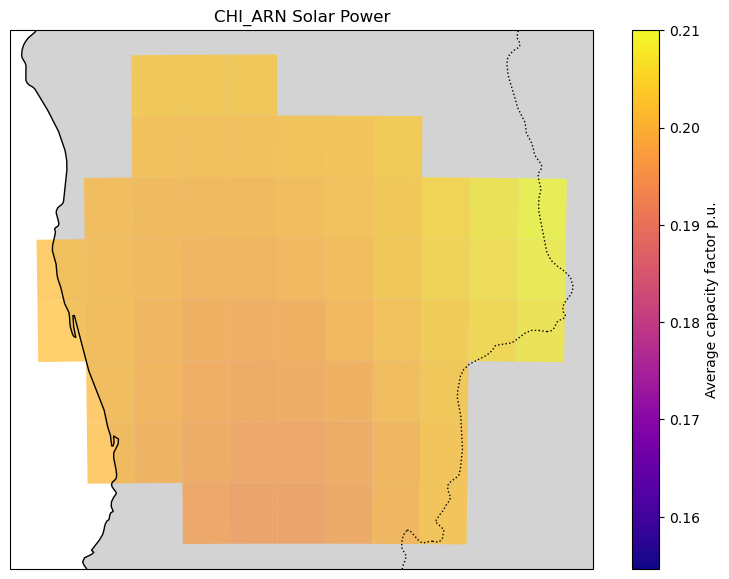

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from matplotlib.patches import Rectangle
import cartopy.feature as cfeature

def get_avg_values(power_file):
    power_df = pd.read_csv(power_file, index_col=0, parse_dates=True)
    avg_df = power_df.mean(axis=0).reset_index()
    avg_df.columns = ['location', 'avg_power']
    avg_df[['lat', 'lon']] = avg_df['location'].str.split('_', expand=True).astype(float)
    return avg_df

iso3_code = identifier  # CHI_ARN
wind_power_file  = os.path.join(save_path, f'{iso3_code}_wind_power_profile.csv')
solar_power_file = os.path.join(save_path, f'{iso3_code}_solar_power_profile.csv')

wind_avg  = get_avg_values(wind_power_file)
solar_avg = get_avg_values(solar_power_file)

def plot_static_map(df, title, cmap_name, filename):
    projection = ccrs.LambertAzimuthalEqualArea(central_latitude=df['lat'].mean(), central_longitude=df['lon'].mean())
    fig, ax = plt.subplots(figsize=(10, 7), subplot_kw={'projection': projection})
    ax.add_feature(cfeature.COASTLINE)
    ax.add_feature(cfeature.BORDERS, linestyle=':')
    ax.add_feature(cfeature.LAND, facecolor='lightgray')
    cmap = plt.colormaps.get_cmap(cmap_name)
    for i, row in df.iterrows():
        rect = Rectangle(
            (row['lon'] - 0.125, row['lat'] - 0.125), 0.25, 0.25,
            facecolor=cmap(row['avg_power'] / df['avg_power'].max()),
            edgecolor='none', alpha=0.7, transform=ccrs.PlateCarree()
        )
        ax.add_patch(rect)
    scatter = ax.scatter(df['lon'], df['lat'], c=df['avg_power'], cmap=cmap_name, s=0, transform=ccrs.PlateCarree())
    plt.colorbar(scatter, ax=ax, orientation="vertical").set_label('Average capacity factor p.u.')
    plt.title(title)
    plt.savefig(f'{filename}.png')
    plt.show()

plot_static_map(wind_avg,  f'{identifier} Wind Power',  'viridis', f'{identifier}_wind_power_map_1')
plot_static_map(solar_avg, f'{identifier} Solar Power', 'plasma',  f'{identifier}_solar_power_map_1')

In [7]:
import pandas as pd
import geopandas as gpd
from shapely.geometry import Polygon

def load_pv_power_profile_to_geodataframe(pv_csv_path):
    pv_df = pd.read_csv(pv_csv_path, index_col='datetime')
    locations = pv_df.columns
    coordinates = [tuple(map(float, loc.split('_'))) for loc in locations]

    def create_grid_polygon(lat, lon, resolution=0.25):
        half_res = resolution / 2.0
        return Polygon([
            (lon - half_res, lat - half_res),
            (lon + half_res, lat - half_res),
            (lon + half_res, lat + half_res),
            (lon - half_res, lat + half_res)
        ])

    polygons = [create_grid_polygon(lat, lon) for lat, lon in coordinates]
    geo_df = gpd.GeoDataFrame({'location': locations, 'geometry': polygons}, crs="EPSG:4326")
    return geo_df

pv_csv_path = os.path.join(save_path, f"{identifier}_solar_power_profile.csv")
pv_geodf = load_pv_power_profile_to_geodataframe(pv_csv_path)
pv_geodf.head()

,location,geometry
0,-39.50_-72.75,"POLYGON ((-72.875 -39.625, -72.625 -39.625, -7..."
1,-39.50_-72.50,"POLYGON ((-72.625 -39.625, -72.375 -39.625, -7..."
2,-39.50_-72.25,"POLYGON ((-72.375 -39.625, -72.125 -39.625, -7..."
3,-39.50_-72.00,"POLYGON ((-72.125 -39.625, -71.875 -39.625, -7..."
4,-39.50_-71.75,"POLYGON ((-71.875 -39.625, -71.625 -39.625, -7..."


In [8]:
import geopandas as gpd

pv_geodf_projected = pv_geodf.to_crs(epsg=6933)
pv_geodf_projected['area_km2'] = pv_geodf_projected.geometry.area / 1e6
pv_geodf_with_area = pv_geodf_projected.to_crs(epsg=4326)
pv_geodf_with_area[['location', 'area_km2', 'geometry']].head()

,location,area_km2,geometry
0,-39.50_-72.75,596.852224,"POLYGON ((-72.875 -39.625, -72.625 -39.625, -7..."
1,-39.50_-72.50,596.852224,"POLYGON ((-72.625 -39.625, -72.375 -39.625, -7..."
2,-39.50_-72.25,596.852224,"POLYGON ((-72.375 -39.625, -72.125 -39.625, -7..."
3,-39.50_-72.00,596.852224,"POLYGON ((-72.125 -39.625, -71.875 -39.625, -7..."
4,-39.50_-71.75,596.852224,"POLYGON ((-71.875 -39.625, -71.625 -39.625, -7..."


In [9]:
import geopandas as gpd

# Clip each grid cell polygon to the Araucanía boundary.
# Border cells will be reduced to only their Araucanía portion —
# this ensures EE land cover analysis and area_km2 are correct for border cells.

region_proj  = region_boundary.to_crs(pv_geodf_with_area.crs)
region_union = region_proj.unary_union

pv_geodf_with_area['geometry'] = pv_geodf_with_area['geometry'].intersection(region_union)

# Recompute area_km2 from the clipped geometry
pv_geodf_clipped = pv_geodf_with_area.to_crs(epsg=6933)
pv_geodf_with_area['area_km2'] = pv_geodf_clipped.geometry.area / 1e6

print(f"Geometries clipped to Araucanía boundary.")
print(f"Area range: {pv_geodf_with_area['area_km2'].min():.1f} – {pv_geodf_with_area['area_km2'].max():.1f} km²")
print(f"(Interior cells ≈ {pv_geodf_with_area['area_km2'].max():.0f} km², border cells will be smaller)")

C:\Users\Benhd\AppData\Local\Temp\ipykernel_19644\2399781908.py:8: DeprecationWarning:

The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.



Geometries clipped to Araucanía boundary.
Area range: 128.4 – 609.3 km²
(Interior cells ≈ 609 km², border cells will be smaller)


In [12]:
import ee
import geemap
import geopandas as gpd
from shapely.geometry import Polygon
from tqdm import tqdm
import os
import pandas as pd

# Output path uses DATA_OUT and identifier from config
output_file = os.path.join(DATA_OUT, f'{identifier}_renewables_land_cover.csv')

if os.path.exists(output_file):
    print(f"{output_file} already exists. Skipping Earth Engine processing.")
    pv_geodf_with_area = pd.read_csv(output_file)
else:
    ee.Authenticate()
    ee.Initialize()

    modis_landcover = ee.ImageCollection('MODIS/006/MCD12Q1').filterDate('2020-01-01', '2020-12-31').first()
    wdpa_polygons   = ee.FeatureCollection('WCMC/WDPA/current/polygons')
    srtm            = ee.Image('USGS/SRTMGL1_003')
    slope           = ee.Terrain.slope(srtm)

    land_availability_factors = {
        0: 0.0,  1: 0.0,  2: 0.0,  3: 0.0,  4: 0.0,  5: 0.0,
        6: 0.5,  7: 0.5,  8: 0.2,  9: 0.2,  10: 0.2, 11: 0.0,
        12: 0.05, 13: 0.03, 14: 0.05, 15: 0.0, 16: 1.0, 17: 0.0
    }

    def shapely_to_ee_polygon(polygon_geometry):
        from shapely.geometry import MultiPolygon as ShapelyMultiPolygon
        if polygon_geometry.is_empty:
            raise ee.EEException("Empty geometry.")
        if isinstance(polygon_geometry, ShapelyMultiPolygon):
            polygon_geometry = max(polygon_geometry.geoms, key=lambda p: p.area)
        exterior_coords = list(polygon_geometry.exterior.coords)
        interiors = [list(interior.coords) for interior in polygon_geometry.interiors]
        return ee.Geometry.Polygon([exterior_coords] + interiors)

    def calculate_land_cover_for_polygon(polygon_geometry, modis_image, land_availability_factors):
        try:
            ee_polygon = shapely_to_ee_polygon(polygon_geometry)
            modis_clipped = modis_image.clip(ee_polygon)
            landcover_classification = modis_clipped.select('LC_Type1')

            protected_areas = wdpa_polygons.map(lambda f: f.set('mask', 1))
            protected_areas_raster = protected_areas.reduceToImage(
                properties=['mask'], reducer=ee.Reducer.first()
            ).clip(ee_polygon).unmask(0).rename('protected_mask')
            protected_mask = protected_areas_raster.eq(0)

            slope_clipped = slope.clip(ee_polygon)
            slope_mask    = slope_clipped.lte(15)
            combined_mask = protected_mask.And(slope_mask)
            landcover_masked = landcover_classification.updateMask(combined_mask)

            landcover_histogram = landcover_masked.reduceRegion(
                reducer=ee.Reducer.frequencyHistogram(),
                geometry=ee_polygon, scale=500, maxPixels=1e13
            ).getInfo().get('LC_Type1', {})

            total_pixels = sum(landcover_histogram.values())
            if total_pixels == 0:
                return None, 0.0, None

            available_land_fraction = 0
            primary_land_cover_type = None
            max_pixels = 0

            for land_type, pixel_count in landcover_histogram.items():
                fraction = pixel_count / total_pixels
                if int(land_type) in land_availability_factors:
                    available_land_fraction += fraction * land_availability_factors[int(land_type)]
                if pixel_count > max_pixels:
                    primary_land_cover_type = int(land_type)
                    max_pixels = pixel_count

            return {}, available_land_fraction, primary_land_cover_type

        except ee.EEException as e:
            print(f"Error processing polygon: {e}")
            return None, None, None

    pv_geodf_with_area['available_land_fraction']  = 0.0
    pv_geodf_with_area['available_land_area_km2']  = 0.0
    pv_geodf_with_area['primary_land_cover_type']  = None
    no_available_land_count = 0

    for idx, row in tqdm(pv_geodf_with_area.iterrows(), total=len(pv_geodf_with_area), desc="Processing polygons"):
        _, available_land_fraction, primary_land_cover_type = calculate_land_cover_for_polygon(
            row['geometry'], modis_landcover, land_availability_factors)

        if available_land_fraction is not None:
            pv_geodf_with_area.at[idx, 'available_land_fraction'] = available_land_fraction
            pv_geodf_with_area.at[idx, 'available_land_area_km2'] = row['area_km2'] * available_land_fraction
            pv_geodf_with_area.at[idx, 'primary_land_cover_type'] = primary_land_cover_type
        else:
            pv_geodf_with_area.at[idx, 'available_land_fraction'] = 0.0
            pv_geodf_with_area.at[idx, 'available_land_area_km2'] = 0.0
            pv_geodf_with_area.at[idx, 'primary_land_cover_type'] = 17

        if available_land_fraction == 0.0:
            no_available_land_count += 1

    print(f"Total polygons with no available land: {no_available_land_count}")

    pv_geodf_no_geometry = pv_geodf_with_area.drop(columns=['geometry'])
    pv_geodf_no_geometry.to_csv(output_file, index=False)
    print(f"Data saved to {output_file}")

pv_geodf_with_area[['location', 'area_km2', 'available_land_fraction', 'available_land_area_km2', 'primary_land_cover_type']].head()

Processing polygons: 100%|██████████| 63/63 [00:35<00:00,  1.77it/s]

Total polygons with no available land: 15
Data saved to ./data_Araucania\CHI_ARN_renewables_land_cover.csv


,location,area_km2,available_land_fraction,available_land_area_km2,primary_land_cover_type
0,-39.50_-72.75,128.381585,0.044915,5.766301,2
1,-39.50_-72.50,219.162005,0.053790,11.788670,2
2,-39.50_-72.25,322.210465,0.075084,24.192945,2
3,-39.50_-72.00,191.061388,0.000000,0.000000,17
4,-39.50_-71.75,330.014643,0.000000,0.000000,None


In [13]:
pv_geodf_with_area.describe()

,area_km2,available_land_fraction,available_land_area_km2
count,63.000000,63.000000,63.000000
mean,499.803721,0.085110,41.422257
std,151.493664,0.124203,45.215519
min,128.381585,0.000000,0.000000
25%,438.326796,0.009349,2.373494
50%,598.958909,0.066111,27.093140
75%,603.137491,0.124970,74.172015
max,609.317867,0.900000,258.462840


In [14]:
pv_geodf_with_area['primary_land_cover_type'].value_counts()

primary_land_cover_type
2     24
9     16
5      4
10     2
12     2
17     1
16     1
Name: count, dtype: int64

In [15]:
import geopandas as gpd
from shapely.geometry import Point

output_file_with_offshore = os.path.join(DATA_OUT, f'{identifier}_renewables_land_cover_with_offshore.csv')

if include_offshore:
    def load_country_boundaries(country, land_shapefile_path, eez_shapefile_path, include_offshore):
        if include_offshore:
            eez_gdf = gpd.read_file(eez_shapefile_path)
            country_eez_gdf = eez_gdf[(eez_gdf['TERRITORY1'] == country) | (eez_gdf['TERRITORY2'] == country)]
        else:
            country_eez_gdf = None
        land_gdf = gpd.read_file(land_shapefile_path)
        return land_gdf, country_eez_gdf

    admin_gdf, country_eez_gdf = load_country_boundaries(
        "Chile", land_shapefile_path, eez_shapefile_path, include_offshore
    )

    def parse_location_to_point(location_str):
        lat, lon = map(float, location_str.split('_'))
        return Point(lon, lat)

    pv_geodf_with_area['geometry'] = pv_geodf_with_area['location'].apply(parse_location_to_point)
    pv_geodf_with_area = gpd.GeoDataFrame(pv_geodf_with_area, geometry='geometry', crs=admin_gdf.crs)

    for idx, row in pv_geodf_with_area.iterrows():
        point    = row['geometry']
        in_eez   = country_eez_gdf.contains(point).any() if country_eez_gdf is not None else False
        on_land  = admin_gdf.contains(point).any()
        if in_eez and not on_land:
            pv_geodf_with_area.at[idx, 'primary_land_cover_type']  = 18
            pv_geodf_with_area.at[idx, 'available_land_fraction']  = 0
            pv_geodf_with_area.at[idx, 'available_land_area_km2']  = row['area_km2'] * 1.0
            print('found offshore!')

    pv_geodf_with_area.drop(columns=['geometry']).to_csv(output_file_with_offshore, index=False)
    print(f"Land cover with offshore classification saved to {output_file_with_offshore}")

else:
    # No offshore for Araucanía — save land cover CSV directly under the _with_offshore name
    # (preserves downstream naming convention)
    if 'geometry' in pv_geodf_with_area.columns:
        pv_geodf_with_area.drop(columns=['geometry']).to_csv(output_file_with_offshore, index=False)
    else:
        pv_geodf_with_area.to_csv(output_file_with_offshore, index=False)
    print(f"Offshore classification skipped (include_offshore=False).")
    print(f"Land cover data saved to {output_file_with_offshore}")

pv_geodf_with_area[['location', 'area_km2', 'primary_land_cover_type', 'available_land_fraction', 'available_land_area_km2']].head()

Offshore classification skipped (include_offshore=False).
Land cover data saved to ./data_Araucania\CHI_ARN_renewables_land_cover_with_offshore.csv


,location,area_km2,primary_land_cover_type,available_land_fraction,available_land_area_km2
0,-39.50_-72.75,128.381585,2,0.044915,5.766301
1,-39.50_-72.50,219.162005,2,0.053790,11.788670
2,-39.50_-72.25,322.210465,2,0.075084,24.192945
3,-39.50_-72.00,191.061388,17,0.000000,0.000000
4,-39.50_-71.75,330.014643,None,0.000000,0.000000


# Plotting

C:\Users\Benhd\AppData\Local\Temp\ipykernel_19644\2734932026.py:8: FutureWarning:

Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`



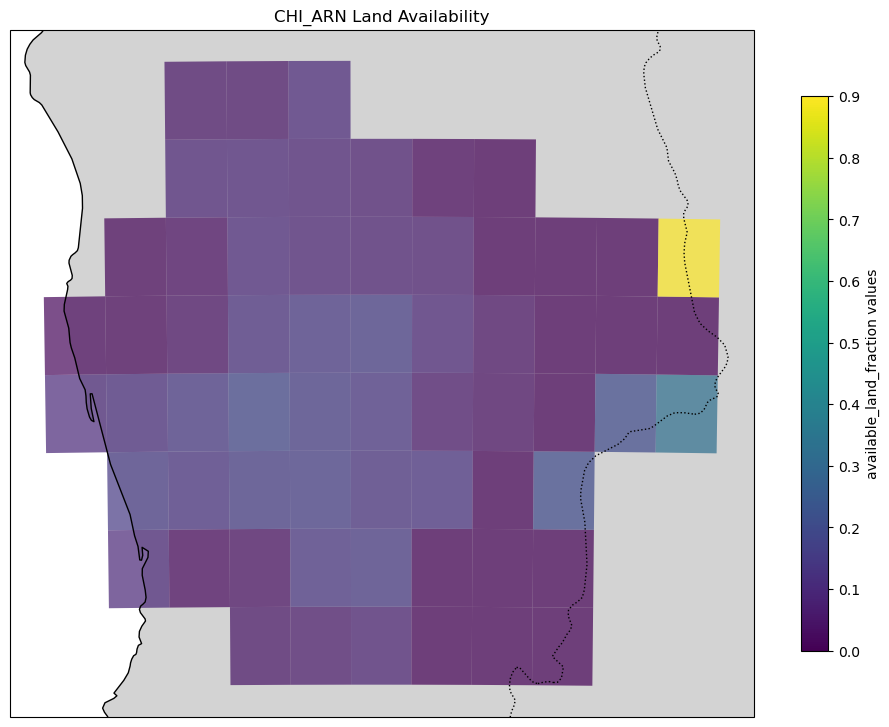

In [16]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from matplotlib.patches import Rectangle
import cartopy.feature as cfeature
import matplotlib.patches as mpatches

pv_geodf_with_area[['lat', 'lon']] = pv_geodf_with_area['location'].str.split('_', expand=True).astype(float)
pv_geodf_with_area['primary_land_cover_type'] = pv_geodf_with_area['primary_land_cover_type'].fillna(17).astype(int)

def plot_continuous_map(df, title, cmap_name, filename, column):
    projection = ccrs.LambertAzimuthalEqualArea(central_latitude=df['lat'].mean(), central_longitude=df['lon'].mean())
    fig, ax = plt.subplots(figsize=(12, 12), subplot_kw={'projection': projection})
    ax.add_feature(cfeature.COASTLINE)
    ax.add_feature(cfeature.BORDERS, linestyle=':')
    ax.add_feature(cfeature.LAND, facecolor='lightgray')
    cities = cfeature.NaturalEarthFeature(category='cultural', name='populated_places', scale='10m')
    ax.add_feature(cities, facecolor='none', edgecolor='black')
    cmap = plt.get_cmap(cmap_name)
    norm = plt.Normalize(vmin=df[column].min(), vmax=df[column].max())
    for i, row in df.iterrows():
        rect = Rectangle(
            (row['lon'] - 0.125, row['lat'] - 0.125), 0.25, 0.25,
            facecolor=cmap(norm(row[column])), edgecolor='none', alpha=0.7,
            transform=ccrs.PlateCarree()
        )
        ax.add_patch(rect)
    scatter = ax.scatter(df['lon'], df['lat'], c=df[column], cmap=cmap, s=0,
                         transform=ccrs.PlateCarree(), norm=norm)
    plt.colorbar(scatter, ax=ax, orientation="vertical", shrink=0.6).set_label(f'{column} values')
    plt.title(title)
    plt.savefig(f'{filename}.png')
    plt.show()

plot_continuous_map(pv_geodf_with_area, f'{identifier} Land Availability', 'viridis',
                    f'{identifier}_land_availability_map', column='available_land_fraction')

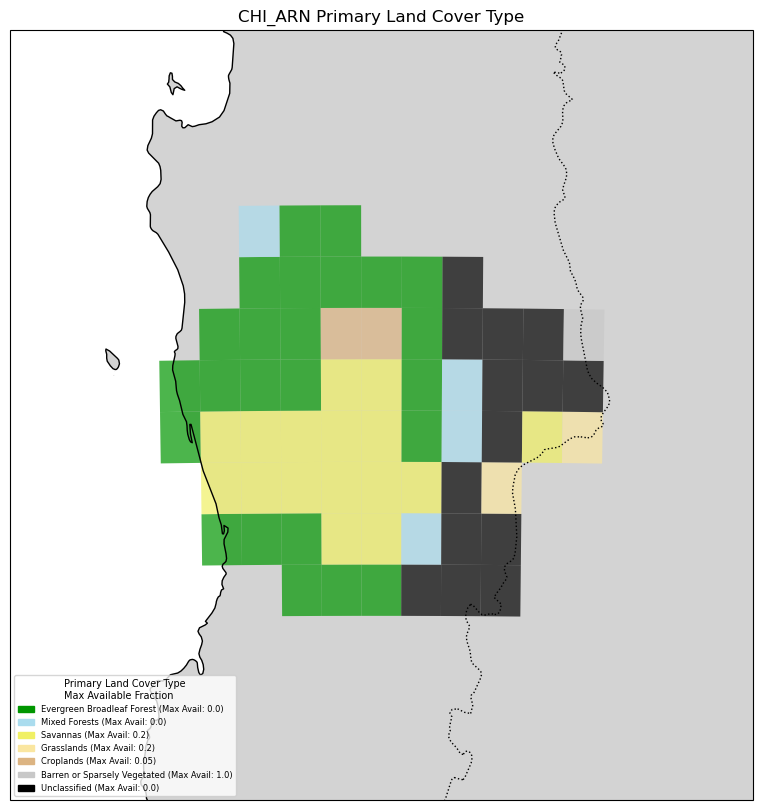

In [17]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from matplotlib.patches import Rectangle
import cartopy.feature as cfeature
import matplotlib.patches as mpatches

land_cover_labels = {
    0: "Water", 1: "Evergreen Needleleaf Forest", 2: "Evergreen Broadleaf Forest",
    3: "Deciduous Needleleaf Forest", 4: "Deciduous Broadleaf Forest", 5: "Mixed Forests",
    6: "Closed Shrublands", 7: "Open Shrublands", 8: "Woody Savannas", 9: "Savannas",
    10: "Grasslands", 11: "Permanent Wetlands", 12: "Croplands", 13: "Urban and Built-up",
    14: "Cropland/Natural Vegetation Mosaics", 15: "Snow and Ice",
    16: "Barren or Sparsely Vegetated", 17: "Unclassified", 18: "Offshore"
}

land_availability_factors = {
    0: 0.0, 1: 0.0, 2: 0.0, 3: 0.0, 4: 0.0, 5: 0.0,
    6: 0.5, 7: 0.5, 8: 0.2, 9: 0.2, 10: 0.2, 11: 0.0,
    12: 0.05, 13: 0.03, 14: 0.05, 15: 0.0, 16: 1.0, 17: 0.0, 18: 1.0
}

modis_colors = {
    0: '#0046C8', 1: '#006400', 2: '#009600', 3: '#009664', 4: '#00C800',
    5: '#AADCEE', 6: '#8C643C', 7: '#B48C46', 8: '#DCDC64', 9: '#F0F064',
    10: '#FAE6A0', 11: '#0078C8', 12: '#DCB482', 13: '#C31400', 14: '#DCDC32',
    15: '#FFFFFF', 16: '#C8C8C8', 17: '#000000', 18: '#6699CC'
}

def plot_categorical_map(df, title, column):
    projection = ccrs.LambertAzimuthalEqualArea(central_latitude=df['lat'].mean(), central_longitude=df['lon'].mean())
    fig, ax = plt.subplots(figsize=(10, 10), subplot_kw={'projection': projection})
    ax.add_feature(cfeature.COASTLINE)
    ax.add_feature(cfeature.BORDERS, linestyle=':')
    ax.add_feature(cfeature.LAND, facecolor='lightgray')
    ax.set_extent([df['lon'].min()-1, df['lon'].max()+1, df['lat'].min()-1, df['lat'].max()+1],
                  crs=ccrs.PlateCarree())
    for i, row in df.iterrows():
        rect = Rectangle(
            (row['lon'] - 0.125, row['lat'] - 0.125), 0.25, 0.25,
            facecolor=modis_colors[row[column]], edgecolor='none', alpha=0.7,
            transform=ccrs.PlateCarree()
        )
        ax.add_patch(rect)
    legend_patches = [mpatches.Patch(color=modis_colors[i],
        label=f"{land_cover_labels[i]} (Max Avail: {land_availability_factors[i]})")
        for i in land_cover_labels if i in pv_geodf_with_area[column].unique()]
    ax.legend(handles=legend_patches, loc='lower left',
              title="Primary Land Cover Type\nMax Available Fraction", fontsize=6, title_fontsize=7)
    plt.title(title)
    plt.show()

pv_geodf_with_area[['lat', 'lon']] = pv_geodf_with_area['location'].str.split('_', expand=True).astype(float)
plot_categorical_map(pv_geodf_with_area, f'{identifier} Primary Land Cover Type',
                     column='primary_land_cover_type')

C:\Users\Benhd\AppData\Local\Temp\ipykernel_19644\2140666022.py:39: UserWarning:

The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.



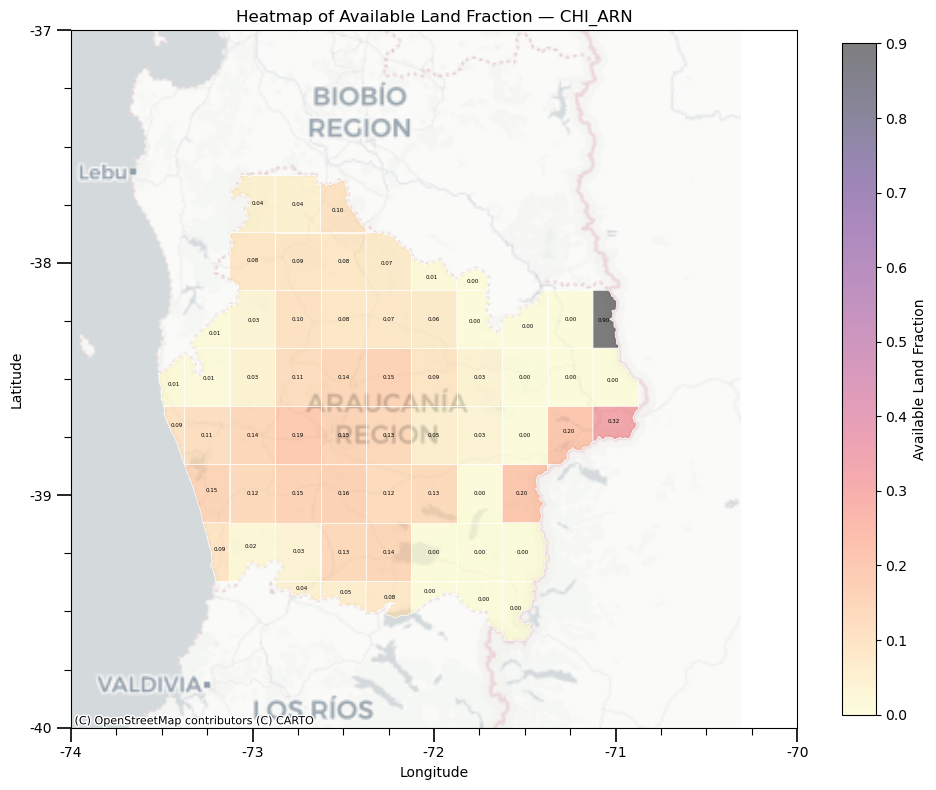

In [18]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import Polygon
import numpy as np
from matplotlib.colors import Normalize
from matplotlib import cm
import contextily as ctx

file_path = os.path.join(DATA_OUT, f'{identifier}_renewables_land_cover_with_offshore.csv')
df = pd.read_csv(file_path)
df[['lat', 'lon']] = df['location'].str.split('_', expand=True).astype(float)

# Use clipped geometries from pv_geodf_with_area (border cells correctly clipped)
df = pd.read_csv(file_path)
df[['lat', 'lon']] = df['location'].str.split('_', expand=True).astype(float)

geom_lookup = pv_geodf_with_area.set_index('location')['geometry']
df['geometry'] = df['location'].map(geom_lookup)
gdf = gpd.GeoDataFrame(df, geometry='geometry', crs='EPSG:4326')

for column in gdf.select_dtypes(include=[np.number]).columns:
    gdf[column] = pd.to_numeric(gdf[column], errors='coerce').replace([np.inf, -np.inf], np.nan).fillna(0)

gdf_excluded = gdf[gdf['primary_land_cover_type'] == 18]
gdf_included = gdf[gdf['primary_land_cover_type'] != 18]

norm = Normalize(vmin=gdf_included['available_land_fraction'].min(),
                 vmax=gdf_included['available_land_fraction'].max())
cmap = cm.magma_r
transparent_cmap_arr = cmap(np.linspace(0, 1, 256))
transparent_cmap_arr[:, 3] = 0.5
transparent_cmap = cm.colors.ListedColormap(transparent_cmap_arr)

gdf_incl_merc = gdf_included.to_crs(epsg=3857)
gdf_excl_merc = gdf_excluded.to_crs(epsg=3857)

fig, ax = plt.subplots(figsize=(12, 8))
gdf_excl_merc.plot(ax=ax, color='lightblue', edgecolor='white', linewidth=0.5)
gdf_incl_merc.plot(ax=ax, column='available_land_fraction', cmap=transparent_cmap,
                   norm=norm, edgecolor='white', linewidth=0.5)

for idx, row in gdf_incl_merc.iterrows():
    plt.annotate(text=f"{row['available_land_fraction']:.2f}",
                 xy=(row['geometry'].centroid.x, row['geometry'].centroid.y),
                 ha='center', va='center', fontsize=4)

ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron, zoom=7)

xlim, ylim = ax.get_xlim(), ax.get_ylim()

def mercator_to_lonlat(x, y):
    lon = x * 180.0 / 20037508.34
    lat = (2 * np.arctan(np.exp(y * np.pi / 20037508.34)) - np.pi / 2) * 180.0 / np.pi
    return lon, lat

lon_start, lon_end = mercator_to_lonlat(xlim[0], 0)[0], mercator_to_lonlat(xlim[1], 0)[0]
lat_start, lat_end = mercator_to_lonlat(0, ylim[0])[1], mercator_to_lonlat(0, ylim[1])[1]
lon_major = np.arange(np.floor(lon_start), np.ceil(lon_end) + 1, 1.0)
lat_major = np.arange(np.floor(lat_start), np.ceil(lat_end) + 1, 1.0)
lon_minor = np.arange(np.floor(lon_start), np.ceil(lon_end) + 0.25, 0.25)
lat_minor = np.arange(np.floor(lat_start), np.ceil(lat_end) + 0.25, 0.25)

def to_merc_x(lon): return xlim[0] + (lon - lon_start) * (xlim[1] - xlim[0]) / (lon_end - lon_start)
def to_merc_y(lat): return ylim[0] + (lat - lat_start) * (ylim[1] - ylim[0]) / (lat_end - lat_start)

ax.set_xticks([to_merc_x(l) for l in lon_major]); ax.set_xticks([to_merc_x(l) for l in lon_minor], minor=True)
ax.set_yticks([to_merc_y(l) for l in lat_major]); ax.set_yticks([to_merc_y(l) for l in lat_minor], minor=True)
ax.set_xticklabels([f"{l:.0f}" for l in lon_major])
ax.set_yticklabels([f"{l:.0f}" for l in lat_major])
ax.tick_params(axis='both', which='major', length=10, width=1.2)
ax.tick_params(axis='both', which='minor', length=5, width=0.8)
ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')

sm = cm.ScalarMappable(cmap=transparent_cmap, norm=norm)
sm._A = []
fig.colorbar(sm, ax=ax, orientation='vertical', fraction=0.03, pad=0.04).set_label('Available Land Fraction')
ax.set_title(f'Heatmap of Available Land Fraction — {identifier}')
plt.tight_layout()
plt.show()

In [19]:
import pandas as pd

combined_df = pd.read_csv(os.path.join(DATA_OUT, f'{identifier}_renewables_land_cover_with_offshore.csv'))
combined_df = combined_df[['location', 'area_km2', 'available_land_area_km2', 'available_land_fraction']].copy()
combined_df[['lat', 'lon']] = combined_df['location'].str.split('_', expand=True).astype(float)

wind_df  = pd.read_csv(os.path.join(DATA_OUT, f'{identifier}_wind_power_profile.csv'),  index_col=0, parse_dates=True)
solar_df = pd.read_csv(os.path.join(DATA_OUT, f'{identifier}_solar_power_profile.csv'), index_col=0, parse_dates=True)

wind_df  = wind_df.apply(pd.to_numeric, errors='coerce')
solar_df = solar_df.apply(pd.to_numeric, errors='coerce')

wind_avg  = wind_df.mean().reset_index();  wind_avg.columns  = ['location', 'wind_cf']
solar_avg = solar_df.mean().reset_index(); solar_avg.columns = ['location', 'solar_cf']

combined_df = combined_df.merge(wind_avg,  on='location', how='left')
combined_df = combined_df.merge(solar_avg, on='location', how='left')

# PCA columns (pc1/pc2/pc3) excluded — run the PCA notebook for CHI_ARN first, then re-add
combined_df = combined_df[['lon', 'lat', 'wind_cf', 'solar_cf', 'area_km2', 'available_land_area_km2', 'available_land_fraction']]
combined_df.columns = ['lon', 'lat', 'wind_cf', 'solar_cf', 'area', 'available_land_area', 'availability_fraction']

out_path = os.path.join(DATA_OUT, f'{identifier}_combined_renewables_land_availability.csv')
combined_df.to_csv(out_path, index=False)
print(f"Combined dataframe saved to {out_path}")
print(combined_df.head())

Combined dataframe saved to ./data_Araucania\CHI_ARN_combined_renewables_land_availability.csv
     lon   lat   wind_cf  solar_cf        area  available_land_area  \
0 -72.75 -39.5  0.114337  0.158872  128.381585             5.766301   
1 -72.50 -39.5  0.089602  0.154622  219.162005            11.788670   
2 -72.25 -39.5  0.056388  0.155186  322.210465            24.192945   
3 -72.00 -39.5  0.044329  0.160231  191.061388             0.000000   
4 -71.75 -39.5  0.070252  0.171108  330.014643             0.000000   

   availability_fraction  
0               0.044915  
1               0.053790  
2               0.075084  
3               0.000000  
4               0.000000  


In [20]:
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point, box

geojson_path = boundary_geojson_path  # data_Araucania/CHI_ARN_boundary.geojson
wind_in  = os.path.join(DATA_OUT, f"{identifier}_wind_power_profile.csv")
solar_in = os.path.join(DATA_OUT, f"{identifier}_solar_power_profile.csv")
wind_out  = os.path.join(DATA_OUT, f"{identifier}_wind_power_profile_trimmed.csv")
solar_out = os.path.join(DATA_OUT, f"{identifier}_solar_power_profile_trimmed.csv")

region = gpd.read_file(geojson_path).to_crs("EPSG:4326").dissolve()

def trim_profile_columns(csv_path, out_path):
    df = pd.read_csv(csv_path, index_col=0, parse_dates=True)
    locations = pd.Index(df.columns, name="location")
    lat_lon   = locations.to_series().str.split("_", expand=True)
    loc_df = pd.DataFrame({
        "location": locations,
        "lat": lat_lon[0].astype(float).values,
        "lon": lat_lon[1].astype(float).values,
    })
    gdf = gpd.GeoDataFrame(loc_df, geometry=gpd.points_from_xy(loc_df["lon"], loc_df["lat"]), crs="EPSG:4326")
    keep = gpd.sjoin(gdf, region, how="inner", predicate="intersects")
    print(f"Trimmed to {len(keep)} cells from {len(loc_df)}")

    half_cell = 0.125
    keep = keep.copy()
    keep['geometry'] = keep.geometry.apply(
        lambda p: box(p.x - half_cell, p.y - half_cell, p.x + half_cell, p.y + half_cell)
    )

    geojson_out = os.path.join(DATA_OUT, f"{identifier}_solar_power_profile_trimmed.geojson")
    keep.to_file(geojson_out, driver="GeoJSON")
    print(f"Trimmed GeoJSON saved to {geojson_out}")

    keep_locations = keep["location"].tolist()
    df_trim = df.loc[:, df.columns.isin(keep_locations)]
    df_trim.to_csv(out_path, index_label="datetime")
    return df_trim

wind_trimmed  = trim_profile_columns(wind_in,  wind_out)
solar_trimmed = trim_profile_columns(solar_in, solar_out)
print(f"Trimmed shapes — wind: {wind_trimmed.shape}, solar: {solar_trimmed.shape}")

Trimmed to 53 cells from 63
Trimmed GeoJSON saved to ./data_Araucania\CHI_ARN_solar_power_profile_trimmed.geojson
Trimmed to 53 cells from 63
Trimmed GeoJSON saved to ./data_Araucania\CHI_ARN_solar_power_profile_trimmed.geojson
Trimmed shapes — wind: (8760, 53), solar: (8760, 53)


Loaded 32 communes


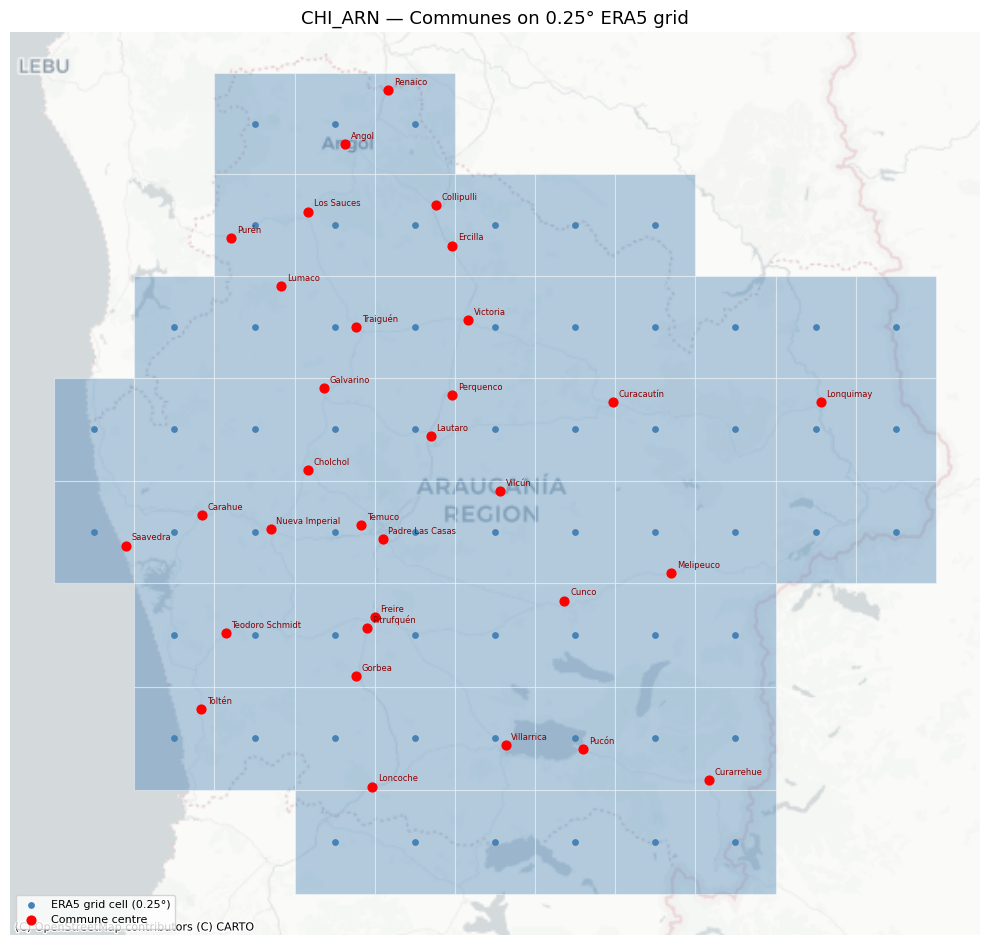

Grid cells: 63
Communes:   32


In [21]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import contextily as ctx
import numpy as np
from shapely.geometry import box
import os

# ── Load data ────────────────────────────────────────────────────────────────
communes = pd.read_csv(os.path.join(DATA_OUT, "Commune_Location.csv"))
print(f"Loaded {len(communes)} communes")

# ── Build 0.25° grid cells from wind profile columns ─────────────────────────
wind_df = pd.read_csv(os.path.join(DATA_OUT, f"{identifier}_wind_power_profile.csv"),
                      index_col=0, nrows=1)  # only need column names
grid_lats = [float(c.split('_')[0]) for c in wind_df.columns]
grid_lons = [float(c.split('_')[1]) for c in wind_df.columns]

grid_cells = gpd.GeoDataFrame(
    {'location': wind_df.columns},
    geometry=[box(lon - 0.125, lat - 0.125, lon + 0.125, lat + 0.125)
              for lat, lon in zip(grid_lats, grid_lons)],
    crs="EPSG:4326"
).to_crs(epsg=3857)

# ── Convert communes to GeoDataFrame ─────────────────────────────────────────
communes_gdf = gpd.GeoDataFrame(
    communes,
    geometry=gpd.points_from_xy(communes['lon'], communes['lat']),
    crs="EPSG:4326"
).to_crs(epsg=3857)

# ── Plot ─────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 12))

# Grid cells
grid_cells.plot(ax=ax, facecolor='steelblue', edgecolor='white',
                linewidth=0.8, alpha=0.4, zorder=2)

# Grid cell centre points
ax.scatter(
    [g.centroid.x for g in grid_cells.geometry],
    [g.centroid.y for g in grid_cells.geometry],
    s=15, color='steelblue', zorder=3, label='ERA5 grid cell (0.25°)'
)

# Commune points
communes_gdf.plot(ax=ax, color='red', markersize=40, zorder=4,
                  marker='o', label='Commune centre')

# Commune labels
for _, row in communes_gdf.iterrows():
    ax.annotate(
        row['commune'],
        xy=(row.geometry.x, row.geometry.y),
        xytext=(4, 4), textcoords='offset points',
        fontsize=6, color='darkred', zorder=5
    )

# Basemap
ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron, zoom=8)

# Pad extent slightly beyond grid bounds
xmin, ymin, xmax, ymax = grid_cells.total_bounds
xpad, ypad = (xmax - xmin) * 0.05, (ymax - ymin) * 0.05
ax.set_xlim(xmin - xpad, xmax + xpad)
ax.set_ylim(ymin - ypad, ymax + ypad)

ax.legend(loc='lower left', fontsize=8)
ax.set_title(f"{identifier} — Communes on 0.25° ERA5 grid", fontsize=13)
ax.set_axis_off()
plt.tight_layout()
plt.show()

print(f"Grid cells: {len(grid_cells)}")
print(f"Communes:   {len(communes_gdf)}")

In [22]:
import geopandas as gpd
import pandas as pd
from shapely.geometry import Point
from shapely.geometry import box
import os

# ── Build grid GeoDataFrame with centre points and cell polygons ──────────────
wind_df_cols = pd.read_csv(
    os.path.join(DATA_OUT, f"{identifier}_wind_power_profile.csv"),
    index_col=0, nrows=1
)

grid_records = []
for col in wind_df_cols.columns:
    lat, lon = map(float, col.split('_'))
    grid_records.append({
        'location': col,
        'lat':      lat,
        'lon':      lon,
        'geometry': box(lon - 0.125, lat - 0.125, lon + 0.125, lat + 0.125)
    })

grid_gdf = gpd.GeoDataFrame(grid_records, crs="EPSG:4326")

# ── Save GeoJSON (polygon cells — use for spatial joins) ─────────────────────
geojson_path = os.path.join(DATA_OUT, f"{identifier}_grid_cells.geojson")
grid_gdf.to_file(geojson_path, driver="GeoJSON")
print(f"Grid GeoJSON saved:  {geojson_path}")

# ── Save CSV (location / lat / lon — use for appending tabular data) ─────────
csv_path = os.path.join(DATA_OUT, f"{identifier}_grid_index.csv")
grid_gdf[['location', 'lat', 'lon']].to_csv(csv_path, index=False)
print(f"Grid index CSV saved: {csv_path}")

print(f"\nGrid cells: {len(grid_gdf)}")
print(grid_gdf[['location', 'lat', 'lon']].head())

Grid GeoJSON saved:  ./data_Araucania\CHI_ARN_grid_cells.geojson
Grid index CSV saved: ./data_Araucania\CHI_ARN_grid_index.csv

Grid cells: 63
        location   lat    lon
0  -39.50_-72.75 -39.5 -72.75
1  -39.50_-72.50 -39.5 -72.50
2  -39.50_-72.25 -39.5 -72.25
3  -39.50_-72.00 -39.5 -72.00
4  -39.50_-71.75 -39.5 -71.75


In [23]:
pv_geodf_with_area[['location', 'area_km2', 'available_land_fraction', 
                     'available_land_area_km2', 'primary_land_cover_type']].sort_values('available_land_fraction', ascending=False).head(5)

,location,area_km2,available_land_fraction,available_land_area_km2,primary_land_cover_type
53,-38.25_-71.00,287.180933,0.900000,258.462840,16
32,-38.75_-71.00,305.123138,0.321569,98.118029,10
31,-38.75_-71.25,504.495152,0.200000,100.899030,9
21,-39.00_-71.50,508.174552,0.200000,101.634910,10
25,-38.75_-72.75,603.137491,0.185091,111.635496,9


In [24]:
import pandas as pd
import geopandas as gpd
from shapely.geometry import box
import numpy as np
import os

# ── Constants ─────────────────────────────────────────────────────────────────
H2_LHV_MWH_PER_TONNE = 33.33   # LHV of hydrogen: 120 MJ/kg = 33.33 MWh/tonne

# ── 2023 month hours (non-leap year) ─────────────────────────────────────────
MONTH_HOURS = {
    'January': 744, 'February': 672, 'March': 744, 'April': 720,
    'May': 744, 'June': 720, 'July': 744, 'August': 744,
    'September': 720, 'October': 744, 'November': 720, 'December': 744,
}
MONTH_NUM = {
    'January': 1, 'February': 2, 'March': 3, 'April': 4,
    'May': 5, 'June': 6, 'July': 7, 'August': 8,
    'September': 9, 'October': 10, 'November': 11, 'December': 12,
}
month_num_to_name = {v: k for k, v in MONTH_NUM.items()}

# ── Load grid cell columns from non-trimmed solar profile (63 cells) ──────────
solar_cols = pd.read_csv(
    os.path.join(DATA_OUT, f"{identifier}_solar_power_profile.csv"),
    index_col=0, nrows=1
).columns.tolist()
print(f"Grid cells (non-trimmed): {len(solar_cols)}")

grid_boxes = gpd.GeoDataFrame(
    {'location': solar_cols},
    geometry=[box(float(c.split('_')[1]) - 0.125,
                  float(c.split('_')[0]) - 0.125,
                  float(c.split('_')[1]) + 0.125,
                  float(c.split('_')[0]) + 0.125) for c in solar_cols],
    crs="EPSG:4326"
)

# ── Spatial join: commune points → grid cells ─────────────────────────────────
communes_loc = pd.read_csv(os.path.join(DATA_OUT, "Commune_Location.csv"))
communes_gdf = gpd.GeoDataFrame(
    communes_loc,
    geometry=gpd.points_from_xy(communes_loc['lon'], communes_loc['lat']),
    crs="EPSG:4326"
)

joined = gpd.sjoin(communes_gdf, grid_boxes, how="left", predicate="within")
unmatched = joined[joined['index_right'].isna()]['commune'].tolist()
if unmatched:
    print(f"WARNING — {len(unmatched)} communes not matched to any cell: {unmatched}")
else:
    print(f"All {len(communes_gdf)} communes matched to a grid cell.")

commune_to_cell = joined[['commune', 'location']].dropna()

# ── Load monthly demand, melt, merge, aggregate per (month, cell) ─────────────
demand_df = pd.read_csv(os.path.join(DATA_OUT, "60%_H2_Commune_Demand.csv"))
demand_long = demand_df.melt(id_vars='month', var_name='commune', value_name='demand_tonnes')
demand_long = demand_long.merge(commune_to_cell, on='commune', how='left')

unmatched_rows = demand_long[demand_long['location'].isna()]['commune'].unique()
if len(unmatched_rows):
    print(f"WARNING — demand rows with no cell match: {unmatched_rows}")

cell_monthly = (
    demand_long.dropna(subset=['location'])
    .groupby(['month', 'location'])['demand_tonnes']
    .sum()
    .reset_index()
)
cell_monthly['demand_MWh'] = cell_monthly['demand_tonnes'] * H2_LHV_MWH_PER_TONNE
cell_monthly['hourly_rate'] = cell_monthly.apply(
    lambda r: r['demand_MWh'] / MONTH_HOURS[r['month']], axis=1
)

# Pivot to (month_name × cell) lookup table; fill cells with no demand = 0
hourly_rate_lookup = (
    cell_monthly.pivot(index='month', columns='location', values='hourly_rate')
    .reindex(columns=solar_cols, fill_value=0.0)
    .fillna(0.0)
)

# ── Build 8760-row hourly timeseries ──────────────────────────────────────────
hourly_index = pd.date_range("2023-01-01", periods=8760, freq="h")
demand_hourly = pd.DataFrame(
    [hourly_rate_lookup.loc[month_num_to_name[ts.month]].values for ts in hourly_index],
    index=hourly_index,
    columns=solar_cols
)

# ── Save ──────────────────────────────────────────────────────────────────────
out_path = os.path.join(DATA_OUT, f"{identifier}_H2_demand_MWh.csv")
demand_hourly.to_csv(out_path, index_label="datetime")
print(f"\nSaved: {out_path}")
print(f"Shape: {demand_hourly.shape}  (expected 8760 × {len(solar_cols)})")

# ── Verification: January total ───────────────────────────────────────────────
jan_out = demand_hourly[demand_hourly.index.month == 1].sum().sum()
jan_exp = demand_df.set_index('month').loc['January'].sum() * H2_LHV_MWH_PER_TONNE
print(f"\nVerification — January total:")
print(f"  Output:   {jan_out:.2f} MWh")
print(f"  Expected: {jan_exp:.2f} MWh")
print(f"  Match:    {np.isclose(jan_out, jan_exp)}")

Grid cells (non-trimmed): 63
All 32 communes matched to a grid cell.

Saved: ./data_Araucania\CHI_ARN_H2_demand_MWh.csv
Shape: (8760, 63)  (expected 8760 × 63)

Verification — January total:
  Output:   311675.06 MWh
  Expected: 311675.06 MWh
  Match:    True


In [1]:
import requests, geopandas as gpd

resp = requests.get(
    "https://www.geoboundaries.org/api/current/gbOpen/CHL/ADM2/",
    timeout=15
)
communes_all = gpd.read_file(resp.json()["gjDownloadURL"])

# Araucanía communes span two provinces: Cautín and Malleco
araucania_communes = communes_all[
    communes_all['shapeGroup'] == 'CHL'
].to_crs("EPSG:4326")

# Filter spatially against the known boundary
boundary = gpd.read_file("../data_Araucania/CHI_ARN_boundary.geojson").to_crs("EPSG:4326")
araucania_communes = gpd.sjoin(araucania_communes, boundary, how="inner", predicate="intersects")

print(f"Found {len(araucania_communes)} communes")

Found 5 communes


In [3]:
import requests, geopandas as gpd

resp = requests.get(
    "https://www.geoboundaries.org/api/current/gbOpen/CHL/ADM3/",
    timeout=15
)
communes_all = gpd.read_file(resp.json()["gjDownloadURL"]).to_crs("EPSG:4326")

boundary = gpd.read_file("../data_Araucania/CHI_ARN_boundary.geojson").to_crs("EPSG:4326")
boundary_union = boundary.unary_union

# Keep only communes whose centroid falls inside Araucanía
araucania_communes = communes_all[
    communes_all.geometry.centroid.within(boundary_union)
].copy()

print(f"Found {len(araucania_communes)} communes")
print(sorted(araucania_communes['shapeName'].tolist()))

C:\Users\Benhd\AppData\Local\Temp\ipykernel_10088\2603692467.py:10: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  boundary_union = boundary.unary_union


Found 32 communes
['Angol', 'Carahue', 'Cholchol', 'Collipulli', 'Cunco', 'Curacautín', 'Curarrehue', 'Ercilla', 'Freire', 'Galvarino', 'Gorbea', 'Lautaro', 'Loncoche', 'Lonquimay', 'Los Sauces', 'Lumaco', 'Melipeuco', 'Nueva Imperial', 'Padre Las Casas', 'Perquenco', 'Pitrufquén', 'Pucón', 'Purén', 'Renaico', 'Saavedra', 'Temuco', 'Teodoro Schmidt', 'Toltén', 'Traiguén', 'Victoria', 'Vilcún', 'Villarrica']


C:\Users\Benhd\AppData\Local\Temp\ipykernel_10088\2603692467.py:14: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  communes_all.geometry.centroid.within(boundary_union)


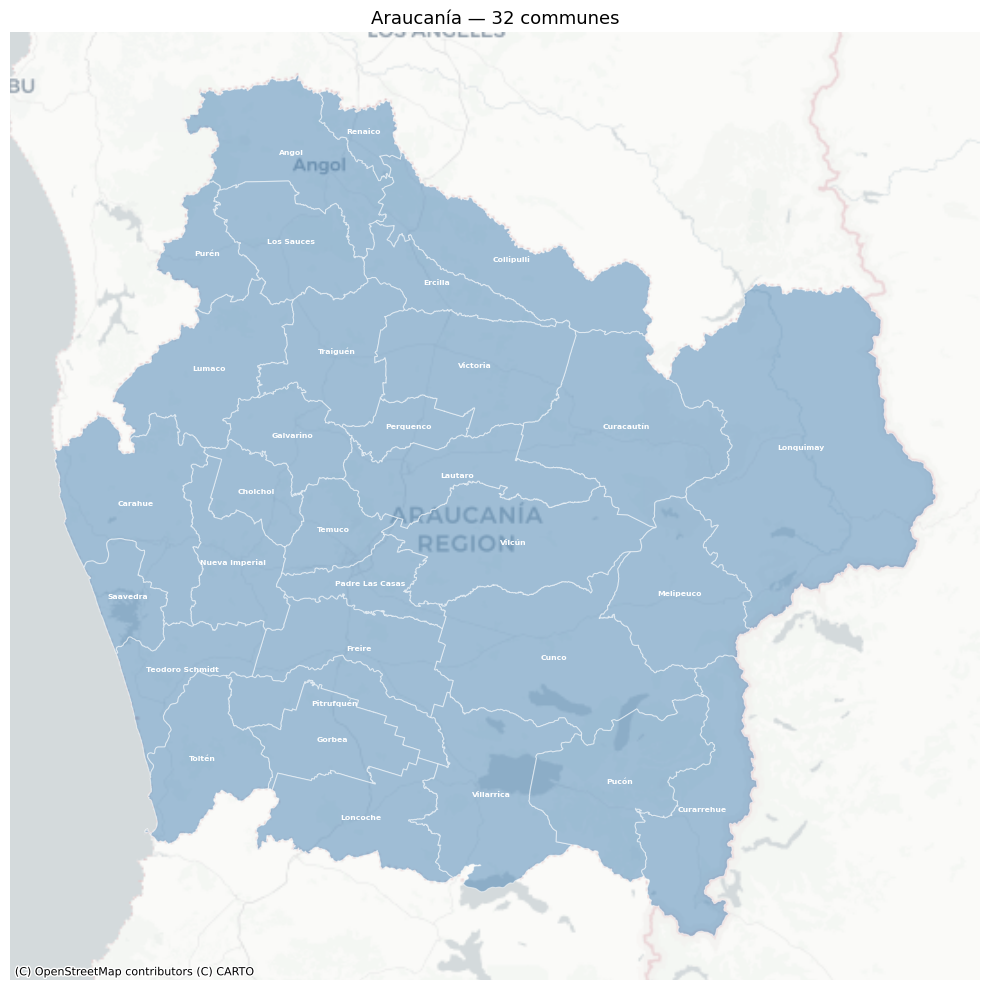

In [4]:
import matplotlib.pyplot as plt
import contextily as ctx

fig, ax = plt.subplots(figsize=(10, 12))

araucania_communes_merc = araucania_communes.to_crs(epsg=3857)

araucania_communes_merc.plot(
    ax=ax, facecolor='steelblue', edgecolor='white',
    linewidth=0.8, alpha=0.5, zorder=2
)

# Label each commune
for _, row in araucania_communes_merc.iterrows():
    cx = row.geometry.centroid.x
    cy = row.geometry.centroid.y
    ax.annotate(
        row['shapeName'],
        xy=(cx, cy), ha='center', va='center',
        fontsize=5.5, color='white', fontweight='bold', zorder=3
    )

ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron, zoom=8)

xmin, ymin, xmax, ymax = araucania_communes_merc.total_bounds
xpad, ypad = (xmax - xmin) * 0.05, (ymax - ymin) * 0.05
ax.set_xlim(xmin - xpad, xmax + xpad)
ax.set_ylim(ymin - ypad, ymax + ypad)

ax.set_title(f"Araucanía — {len(araucania_communes)} communes", fontsize=13)
ax.set_axis_off()
plt.tight_layout()
plt.show()

In [5]:
import os
os.makedirs("../data_Araucania/araucania_communes", exist_ok=True)
araucania_communes.to_file("../data_Araucania/araucania_communes/araucania_communes.shp")
print("Saved to ../data_Araucania/araucania_communes/araucania_communes.shp")
print(f"Columns: {araucania_communes.columns.tolist()}")

Saved to ../data_Araucania/araucania_communes/araucania_communes.shp
Columns: ['shapeName', 'shapeISO', 'shapeID', 'shapeGroup', 'shapeType', 'geometry']
